### Importing libraries

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [9]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [10]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance_on_an_entrance_examination = fetch_ucirepo(id=582) 
  
# data (as pandas dataframes) 
X = student_performance_on_an_entrance_examination.data.features 
y = student_performance_on_an_entrance_examination.data.targets 
  
# metadata 
print(student_performance_on_an_entrance_examination.metadata) 
  
# variable information 
print(student_performance_on_an_entrance_examination.variables) 


{'uci_id': 582, 'name': 'Student Performance on an Entrance Examination', 'repository_url': 'https://archive.ics.uci.edu/dataset/582/student+performance+on+an+entrance+examination', 'data_url': 'https://archive.ics.uci.edu/static/public/582/data.csv', 'abstract': 'This dataset contains data of the candidates who qualified the medical entrance examination for admission to medical colleges of Assam of a particular year and collected by Prof. Jiten Hazarika.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 666, 'num_features': 11, 'feature_types': [], 'demographics': ['Gender', 'Education Level', 'Occupation'], 'target_col': ['Performance'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Tue Apr 16 2024', 'dataset_doi': '10.24432/C58D0H', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Performance, Gender, Caste, coaching, C

In [11]:
X

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO
...,...,...,...,...,...,...,...,...,...,...,...
661,female,ST,WA,SEBA,AHSEC,ENGLISH,Good,Vg,OTHERS,HOUSE_WIFE,ONE
662,male,ST,WA,SEBA,AHSEC,ENGLISH,Vg,Good,CULTIVATOR,HOUSE_WIFE,THREE
663,male,ST,WA,SEBA,CBSE,ENGLISH,Good,Vg,OTHERS,SCHOOL_TEACHER,TWO
664,male,ST,WA,SEBA,AHSEC,ENGLISH,Good,Good,SCHOOL_TEACHER,HOUSE_WIFE,THREE


In [13]:
y

,Performance
0,Excellent
1,Excellent
2,Excellent
3,Excellent
4,Excellent
...,...
661,Average
662,Average
663,Average
664,Average


In [16]:
df=pd.concat([X,y],axis=1).reset_index(drop=True)
# It reset the index from 0

In [18]:
df.head()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE,Excellent
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO,Excellent
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO,Excellent
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE,Excellent
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO,Excellent


In [19]:
# Check for missing value
df.isnull().sum()

Gender                  0
Caste                   0
coaching                0
Class_ten_education     0
twelve_education        0
medium                  0
Class_X_Percentage      0
Class_XII_Percentage    0
Father_occupation       0
Mother_occupation       0
time                    0
Performance             0
dtype: int64

In [20]:
df['Performance'].value_counts()

Performance
Good         210
Vg           198
Average      157
Excellent    101
Name: count, dtype: int64

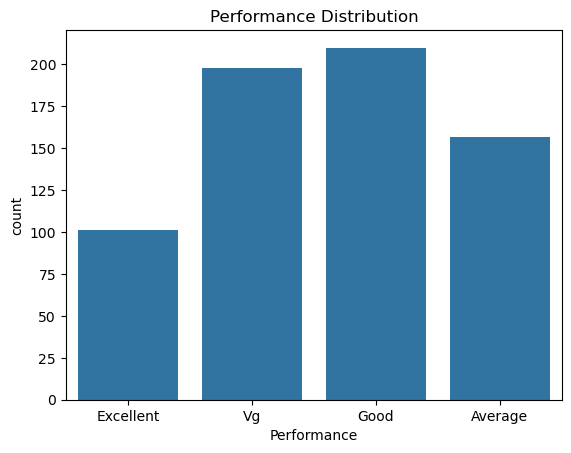

In [21]:
import matplotlib.pyplot as plt
sns.countplot(x=df['Performance'])
plt.title("Performance Distribution")
plt.show()

In [22]:
print(df.shape)

(666, 12)


In [23]:
type(X)
type(y)

pandas.core.frame.DataFrame

In [24]:
df.columns

Index(['Gender', 'Caste', 'coaching', 'Class_ten_education',
       'twelve_education', 'medium', 'Class_X_Percentage',
       'Class_XII_Percentage', 'Father_occupation', 'Mother_occupation',
       'time', 'Performance'],
      dtype='object')

In [26]:
for col in df.columns:
    print(df[col].value_counts())
    print("----------------------------------")

Gender
male      355
female    311
Name: count, dtype: int64
----------------------------------
Caste
General    329
OBC        162
ST         108
SC          67
Name: count, dtype: int64
----------------------------------
coaching
WA    449
NO    150
OA     67
Name: count, dtype: int64
----------------------------------
Class_ten_education
SEBA      396
CBSE      249
OTHERS     21
Name: count, dtype: int64
----------------------------------
twelve_education
AHSEC     368
CBSE      290
OTHERS      8
Name: count, dtype: int64
----------------------------------
medium
ENGLISH     536
OTHERS       74
ASSAMESE     56
Name: count, dtype: int64
----------------------------------
Class_X_Percentage
Excellent    511
Vg           101
Good          41
Average       13
Name: count, dtype: int64
----------------------------------
Class_XII_Percentage
Excellent    398
Vg           181
Good          75
Average       12
Name: count, dtype: int64
----------------------------------
Father_occupation
OT

In [27]:
le=LabelEncoder()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Gender                666 non-null    object
 1   Caste                 666 non-null    object
 2   coaching              666 non-null    object
 3   Class_ten_education   666 non-null    object
 4   twelve_education      666 non-null    object
 5   medium                666 non-null    object
 6   Class_X_Percentage    666 non-null    object
 7   Class_XII_Percentage  666 non-null    object
 8   Father_occupation     666 non-null    object
 9   Mother_occupation     666 non-null    object
 10  time                  666 non-null    object
 11  Performance           666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB


In [28]:
for col in df.columns:
    df[col]=le.fit_transform(df[col])

In [29]:
df.head()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,1,0,0,2,0,1,1,1,4,7,2,1
1,1,1,2,2,0,2,1,1,7,6,5,1
2,1,1,1,1,1,1,1,1,1,6,5,1
3,1,0,2,2,0,2,1,1,7,8,2,1
4,1,0,1,2,1,1,1,1,2,6,5,1


In [30]:
for col in df.columns:
    print(df[col].value_counts())
    print("----------------------------------")

Gender
1    355
0    311
Name: count, dtype: int64
----------------------------------
Caste
0    329
1    162
3    108
2     67
Name: count, dtype: int64
----------------------------------
coaching
2    449
0    150
1     67
Name: count, dtype: int64
----------------------------------
Class_ten_education
2    396
0    249
1     21
Name: count, dtype: int64
----------------------------------
twelve_education
0    368
1    290
2      8
Name: count, dtype: int64
----------------------------------
medium
1    536
2     74
0     56
Name: count, dtype: int64
----------------------------------
Class_X_Percentage
1    511
3    101
2     41
0     13
Name: count, dtype: int64
----------------------------------
Class_XII_Percentage
1    398
3    181
2     75
0     12
Name: count, dtype: int64
----------------------------------
Father_occupation
6    277
7    109
1    103
4     55
5     45
2     27
3     27
0     23
Name: count, dtype: int64
----------------------------------
Mother_occupation
6  

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Gender                666 non-null    int64
 1   Caste                 666 non-null    int64
 2   coaching              666 non-null    int64
 3   Class_ten_education   666 non-null    int64
 4   twelve_education      666 non-null    int64
 5   medium                666 non-null    int64
 6   Class_X_Percentage    666 non-null    int64
 7   Class_XII_Percentage  666 non-null    int64
 8   Father_occupation     666 non-null    int64
 9   Mother_occupation     666 non-null    int64
 10  time                  666 non-null    int64
 11  Performance           666 non-null    int64
dtypes: int64(12)
memory usage: 62.6 KB


In [32]:
#Correlation matrix : Relation b/w features
df.corr()


,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
Gender,1.000000,-0.063499,-0.113041,-0.063879,0.033976,0.111962,0.085434,0.041656,0.053440,0.059056,-0.025586,-0.019460
Caste,-0.063499,1.000000,-0.007023,0.053676,-0.043599,-0.130818,0.125065,0.168382,0.044260,0.042894,0.008103,-0.618730
coaching,-0.113041,-0.007023,1.000000,0.069353,-0.049519,-0.032938,0.056601,0.148134,0.045169,0.003522,0.358201,0.051394
Class_ten_education,-0.063879,0.053676,0.069353,1.000000,-0.772589,0.053351,0.195687,0.106420,0.022617,0.045221,0.005672,-0.053992
twelve_education,0.033976,-0.043599,-0.049519,-0.772589,1.000000,-0.034384,-0.117057,-0.090342,-0.118189,-0.088037,-0.024465,-0.015978
medium,0.111962,-0.130818,-0.032938,0.053351,-0.034384,1.000000,0.116444,0.024635,0.043039,-0.052710,-0.049654,0.176761
Class_X_Percentage,0.085434,0.125065,0.056601,0.195687,-0.117057,0.116444,1.000000,0.372145,-0.047050,0.032372,-0.015149,-0.093193
Class_XII_Percentage,0.041656,0.168382,0.148134,0.106420,-0.090342,0.024635,0.372145,1.000000,-0.034885,0.012547,0.228469,-0.111086
Father_occupation,0.053440,0.044260,0.045169,0.022617,-0.118189,0.043039,-0.047050,-0.034885,1.000000,0.116457,0.045268,-0.018133
Mother_occupation,0.059056,0.042894,0.003522,0.045221,-0.088037,-0.052710,0.032372,0.012547,0.116457,1.000000,0.023029,-0.054479


<Axes: >

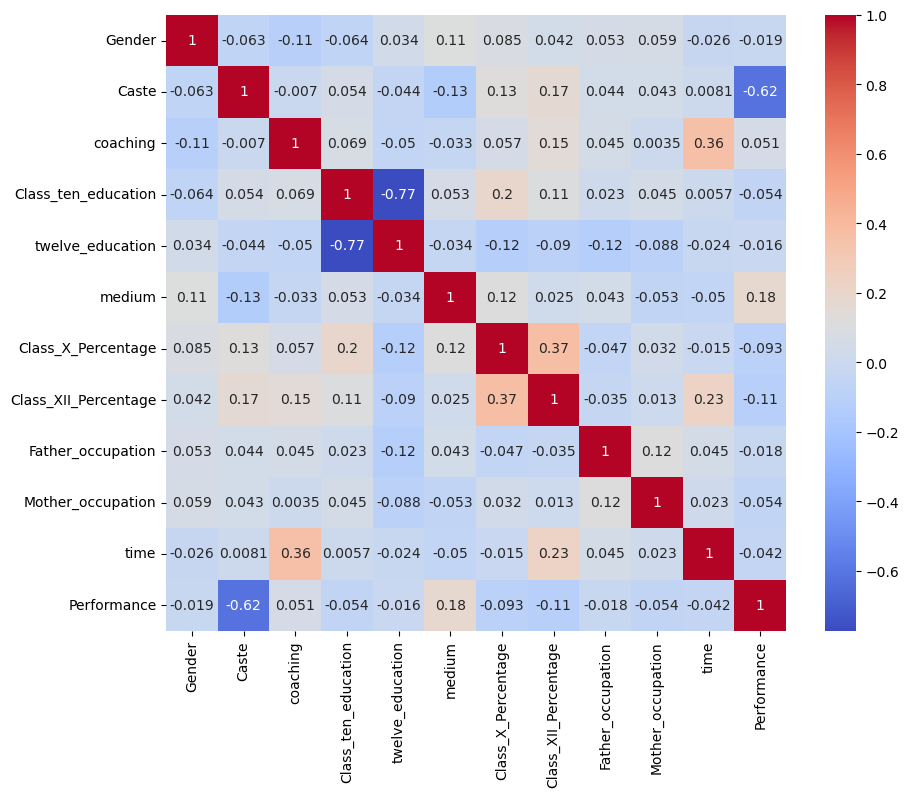

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')


In [35]:
#Feature Engineering


In [36]:
#Combine 10th and 12th performance
df['Academic_score']=df['Class_X_Percentage'] + df['Class_XII_Percentage']

In [37]:
df.head()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance,Academic_score
0,1,0,0,2,0,1,1,1,4,7,2,1,2
1,1,1,2,2,0,2,1,1,7,6,5,1,2
2,1,1,1,1,1,1,1,1,1,6,5,1,2
3,1,0,2,2,0,2,1,1,7,8,2,1,2
4,1,0,1,2,1,1,1,1,2,6,5,1,2


In [38]:
#Seperate the data
X=df.drop('Performance',axis=1)
y=df['Performance']

In [41]:
print(X.head())
print(y.head())

   Gender  Caste  coaching  Class_ten_education  twelve_education  medium  \
0       1      0         0                    2                 0       1   
1       1      1         2                    2                 0       2   
2       1      1         1                    1                 1       1   
3       1      0         2                    2                 0       2   
4       1      0         1                    2                 1       1   

   Class_X_Percentage  Class_XII_Percentage  Father_occupation  \
0                   1                     1                  4   
1                   1                     1                  7   
2                   1                     1                  1   
3                   1                     1                  7   
4                   1                     1                  2   

   Mother_occupation  time  Academic_score  
0                  7     2               2  
1                  6     5               2  
2    

In [55]:
#train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [56]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((532, 12), (134, 12), (532,), (134,))

In [57]:
#model load(rf,xgboost)

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred_rf=rf.predict(X_test)
y_pred_rf

array([1, 2, 0, 0, 3, 3, 1, 2, 3, 3, 3, 0, 3, 2, 2, 2, 3, 1, 2, 1, 3, 1,
       2, 3, 2, 3, 0, 0, 3, 1, 1, 2, 2, 1, 0, 0, 2, 3, 2, 0, 2, 0, 0, 2,
       3, 3, 2, 2, 3, 1, 3, 0, 2, 3, 0, 3, 3, 3, 3, 1, 2, 1, 2, 3, 3, 2,
       3, 0, 2, 3, 2, 1, 0, 3, 0, 2, 1, 2, 0, 1, 2, 3, 2, 0, 3, 2, 1, 2,
       0, 2, 2, 0, 3, 3, 0, 2, 0, 0, 3, 2, 0, 3, 3, 2, 2, 0, 3, 2, 1, 1,
       2, 2, 0, 0, 3, 0, 1, 2, 3, 1, 3, 2, 3, 3, 3, 0, 2, 2, 0, 2, 0, 2,
       2, 2])

In [62]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred_rf,y_test))

0.5671641791044776


In [63]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [64]:
y_pred_gbc=gbc.predict(X_test)
y_pred_gbc

array([3, 3, 0, 0, 3, 2, 1, 2, 2, 2, 3, 0, 2, 0, 3, 2, 3, 1, 0, 2, 3, 1,
       2, 3, 2, 2, 0, 0, 3, 3, 1, 3, 2, 1, 0, 0, 2, 3, 3, 0, 3, 0, 0, 2,
       1, 3, 2, 2, 2, 2, 3, 0, 2, 3, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 3, 3,
       2, 0, 3, 3, 2, 3, 0, 3, 2, 0, 3, 2, 0, 1, 3, 2, 3, 3, 3, 2, 1, 3,
       0, 3, 2, 2, 3, 2, 0, 2, 0, 0, 2, 3, 0, 3, 3, 3, 2, 0, 2, 2, 1, 1,
       2, 2, 0, 0, 2, 0, 1, 2, 1, 3, 3, 3, 2, 3, 3, 0, 2, 1, 0, 2, 0, 2,
       2, 2])

In [65]:
print(accuracy_score(y_pred_gbc,y_test))

0.5895522388059702


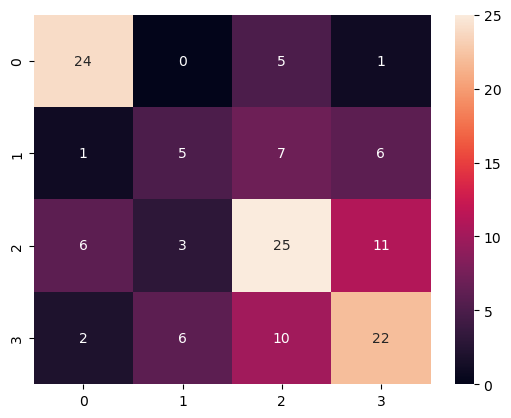

In [69]:
#Confusion matrix for both ensemble methods
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred_rf,y_test)
sns.heatmap(confusion_matrix(y_pred_rf,y_test),annot=True)
plt.show()

In [71]:
print(classification_report(y_pred_rf,y_test))

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        30
           1       0.36      0.26      0.30        19
           2       0.53      0.56      0.54        45
           3       0.55      0.55      0.55        40

    accuracy                           0.57       134
   macro avg       0.54      0.54      0.54       134
weighted avg       0.56      0.57      0.56       134



In [72]:
print(classification_report(y_pred_gbc,y_test))

              precision    recall  f1-score   support

           0       0.76      0.86      0.81        29
           1       0.21      0.21      0.21        14
           2       0.55      0.55      0.55        47
           3       0.62      0.57      0.60        44

    accuracy                           0.59       134
   macro avg       0.54      0.55      0.54       134
weighted avg       0.59      0.59      0.59       134

